# Electric drives, part 5: design margins under uncertainty

A nominal design is a single point in a space of parameters that the real
world refuses to hold still. The winding resistance you etched on the data
sheet drifts ±5% across a production run; magnet remanence varies with the
grade you could actually source that month; and the single number that most
governs how hot the motor gets — the **case-to-ambient thermal resistance
$R_{\mathrm{th}}$** — depends on mounting torque, thermal paste coverage,
airflow, and where the drive ends up bolted in the chassis. Two motors that
pass the same bench test can disagree by 30 °C in the field.

This notebook treats those variations as first-class. We attach probability
distributions to the uncertain parameters, push them through the **validated
closed-form models from Parts 1 and 3**, and ask quantitative questions a
reliability engineer actually signs off on: *Which parameter should I spend
money tightening? How hot is the 1-in-100 motor? At what operating current can
I guarantee `P(overtemp) < 1 %`? How much of the risk could I buy down with
better knowledge, and how much is just the weather?*

**By the end of this notebook you will be able to:**

1. Build a parametric uncertainty model with `jaxonomy.uq` distributions,
   tagging each parameter as **aleatoric** (irreducible operating variation)
   or **epistemic** (reducible manufacturing/model uncertainty).
2. Rank the drivers of a quantity of interest with **Sobol' sensitivity
   indices** (first-order + total), cross-checked with Morris screening.
3. Quantify tail risk with **Value-at-Risk** and **Conditional Value-at-Risk**,
   and convert a reliability spec into a concrete **safe operating current**.
4. **Decompose the risk** into the part you can engineer away (epistemic) and
   the part you must design margin against (aleatoric).

**Reading time** ~25 min · **Runtime** ~1–2 min (all analytic, `vmap`/`jit`-batched, float64).

> **Position in the series.** Parts 1–4 built and validated a single nominal
> interior-PMSM drive (electrical model, FOC current loop, thermal derating,
> efficiency map). Here in **Part 5** we wrap that *verified* nominal model in
> an uncertainty layer to size design margins. Part 6 will take the margin-
> qualified operating envelope to embedded deployment. The closed forms below
> were each checked against the full Jaxonomy ODE simulation in Parts 1 & 3,
> so we use them directly here — they are fast, exact, and `vmap`-friendly,
> which is what makes a 4000-sample Monte Carlo study run in a second.

> **Out of scope.** We do not re-derive or re-simulate the dynamics (see Parts
> 1–3), we do not fit the distributions from measured data (assumed given by
> the supplier/qualification campaign), and we treat the parameters as mutually
> independent. Correlated parameters (`jaxonomy.uq.CorrelatedMarginals`) and
> data-driven distribution fitting are natural extensions left to the reader.


## 1. Setup and the validated nominal model

We enable 64-bit precision (mandatory for both the solver lineage and for
stable tail statistics) and import the `jaxonomy.uq` toolkit. Everything below
is self-contained: the model functions are the closed forms validated in Parts
1 and 3, reproduced here verbatim so this notebook stands alone.

In [1]:
import numpy as np
from jax import config as _c
_c.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jaxonomy.uq as uq

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

print("JAX x64 enabled:", jax.config.jax_enable_x64)
print("uq distributions available:",
      "Normal" in dir(uq), "Uniform" in dir(uq), "LogNormal" in dir(uq))

JAX x64 enabled: True
uq distributions available: True True True


In [2]:
# --- Validated nominal interior-PMSM + lumped-thermal parameters (Parts 1 & 3) ---
NOM = dict(R0=0.45, alpha=0.004, lam0=0.0533, beta=0.0011, p=4.0,
           Ld=3.2e-3, Lq=5.8e-3, R_th=0.30, C_th=30.0, T_ref=25.0, T_amb=25.0)
V_DC = 48.0  # DC bus, as in earlier parts

def Kt(T, lam0, beta, p):
    """Torque constant (N·m/A) at winding temperature T (°C); magnets weaken when hot."""
    return 1.5 * p * lam0 * (1.0 - beta * (T - 25.0))

def steady_dT(i, R0, alpha, R_th):
    """Steady winding temperature *rise* at current magnitude i (A).

    Energy balance: copper loss 1.5 R(T) i^2 == dT / R_th, with
    R(T) = R0 (1 + alpha dT).  Solving the linear equation for dT:
        dT = 1.5 R0 i^2 / (1/R_th - 1.5 R0 alpha i^2).
    Physically valid (positive) only while the denominator > 0, i.e. below i_crit.
    """
    denom = 1.0 / R_th - 1.5 * R0 * alpha * i * i
    return 1.5 * R0 * i * i / denom

def i_crit(R0, alpha, R_th):
    """Thermal-runaway current: denominator of steady_dT vanishes here."""
    return jnp.sqrt(1.0 / (R_th * 1.5 * R0 * alpha))

# Sanity: nominal runaway current and the operating point we will study
I_OP = 14.0       # A — fixed operating current (well below nominal i_crit ≈ 35 A)
T_LIMIT = 155.0   # °C — Class-F winding insulation limit
print(f"nominal i_crit      = {float(i_crit(NOM['R0'], NOM['alpha'], NOM['R_th'])):.2f} A")
print(f"nominal ΔT @ {I_OP:.0f} A   = {float(steady_dT(I_OP, NOM['R0'], NOM['alpha'], NOM['R_th'])):.1f} °C")
print(f"nominal T_wind @ {I_OP:.0f} A = {NOM['T_amb'] + float(steady_dT(I_OP, NOM['R0'], NOM['alpha'], NOM['R_th'])):.1f} °C")

nominal i_crit      = 35.14 A
nominal ΔT @ 14 A   = 47.2 °C
nominal T_wind @ 14 A = 72.2 °C


The nominal motor at $I_{\mathrm{op}}=14\,$A runs around $72\,°$C — a
comfortable margin below the $155\,°$C insulation limit, and the runaway
current $i_{\mathrm{crit}}\approx 35\,$A is far away. On paper this looks safe.
The rest of the notebook asks whether it is *still* safe once every parameter
is allowed to vary, and the answer turns out to depend almost entirely on one
of them.

## 2. The uncertainty model: aleatoric vs. epistemic

We attach a distribution to each uncertain parameter and tag it by **kind**:

- **Epistemic** uncertainty is *reducible* — it reflects limited knowledge of a
  fixed-but-unknown quantity (this motor's actual $R_0$, its magnet grade, its
  as-mounted $R_{\mathrm{th}}$). Tighter manufacturing, better metrology, or a
  calibration step shrinks it.
- **Aleatoric** uncertainty is *irreducible* in the design — it is genuine
  run-to-run randomness the deployed motor will experience. Here the ambient
  temperature $T_{\mathrm{amb}}\in[25,45]\,°$C is the operating environment; no
  amount of measurement removes it.

This distinction is not cosmetic: it determines whether the right response to
risk is *spend money on tolerancing* (epistemic) or *carry design margin /
derate* (aleatoric). We will quantify the split in §7. Concretely: epistemic
variance can in principle be driven to zero by a perfect measurement of the
true parameter value; aleatoric variance cannot, because the quantity is
genuinely different on every duty cycle. A useful litmus test — *"if I built a
million identical copies of this exact motor, would this parameter still vary
across them in service?"* If yes, it is aleatoric (ambient temperature, load);
if no, it is epistemic (this unit's $R_0$, its magnet grade, its mounted
$R_{\mathrm{th}}$).

In [3]:
# Uncertain parameters.  Spreads are 1σ for Normals; [low,high] for Uniform.
DISTS = {
    "R0":    uq.Normal(NOM["R0"],    0.05 * NOM["R0"],    kind="epistemic"),  # ±5% winding mfg
    "alpha": uq.Normal(NOM["alpha"], 0.05 * NOM["alpha"], kind="epistemic"),  # Cu temp-coeff
    "lam0":  uq.Normal(NOM["lam0"],  0.03 * NOM["lam0"],  kind="epistemic"),  # ±3% magnet grade
    "R_th":  uq.Normal(NOM["R_th"],  0.20 * NOM["R_th"],  kind="epistemic"),  # ±20% cooling/mount (DOMINANT)
    "C_th":  uq.Normal(NOM["C_th"],  0.10 * NOM["C_th"],  kind="epistemic"),  # thermal mass
    "T_amb": uq.Uniform(25.0, 45.0,                       kind="aleatoric"),  # operating environment
}
for name, d in DISTS.items():
    print(f"  {name:6s} {type(d).__name__:9s} kind={d.kind}")
print("\naleatoric :", [k for k, v in DISTS.items() if v.kind == "aleatoric"])
print("epistemic :", [k for k, v in DISTS.items() if v.kind == "epistemic"])

  R0     Normal    kind=epistemic
  alpha  Normal    kind=epistemic
  lam0   Normal    kind=epistemic
  R_th   Normal    kind=epistemic
  C_th   Normal    kind=epistemic
  T_amb  Uniform   kind=aleatoric

aleatoric : ['T_amb']
epistemic : ['R0', 'alpha', 'lam0', 'R_th', 'C_th']


## 3. Quantities of interest

A **quantity of interest (QoI)** is a scalar performance/safety figure computed
per sample. We define three, each a pure function of a parameter dict whose
values may be batched (shape `(N,)`) — so the same code evaluates one sample or
four thousand under `vmap`/`jit`:

1. **Steady winding temperature** at the operating current,
   $\;T_{\mathrm{wind}} = T_{\mathrm{amb}} + \Delta T(I_{\mathrm{op}};R_0,\alpha,R_{\mathrm{th}})$.
2. **Margin to thermal runaway**, $\;m = i_{\mathrm{crit}}(R_0,\alpha,R_{\mathrm{th}}) - I_{\mathrm{op}}$.
3. **Hot-point torque** delivered, $\;T_e = K_t(T_{\mathrm{wind}})\,I_{\mathrm{op}}$,
   compared against the cold/nominal target — magnets weaken as the winding
   heats, so the hot motor delivers *less* torque per amp.

The **runaway margin** deserves its closed form spelled out. Setting the
denominator of the steady-state balance to zero gives the current at which the
positive copper-loss/temperature feedback loop becomes unstable:

$$
i_{\mathrm{crit}}(R_0,\alpha,R_{\mathrm{th}}) = \sqrt{\dfrac{1}{R_{\mathrm{th}}\,\tfrac{3}{2}R_0\,\alpha}},
\qquad
m \;=\; i_{\mathrm{crit}}(R_0,\alpha,R_{\mathrm{th}}) - I_{\mathrm{op}}.
$$

Note that all three of $R_0$, $\alpha$, $R_{\mathrm{th}}$ appear *inside the
square root in a product*, so the margin inherits the spread of the worst-known
of them — which, as §5 shows, is $R_{\mathrm{th}}$.

Because `steady_dT` is only physical below $i_{\mathrm{crit}}$ (its denominator
must stay positive), we **guard** it: a sample whose denominator collapses has
run away thermally, which we represent with a large sentinel temperature so it
counts (correctly) as a failure in the tail statistics rather than producing a
`NaN`. This is why the QoI is well-defined across the *entire* parameter
distribution, including the unphysical corner — a NaN there would silently
poison every downstream mean, quantile, and Sobol' estimate.

In [4]:
P, BETA = NOM["p"], NOM["beta"]

def guarded_dT(i, R0, alpha, R_th):
    """steady_dT with a runaway guard: denom<=0 -> thermal runaway (sentinel)."""
    denom = 1.0 / R_th - 1.5 * R0 * alpha * i * i
    safe = denom > 1e-6
    dT = 1.5 * R0 * i * i / jnp.where(safe, denom, 1.0)
    return jnp.where(safe, dT, 1.0e4)   # runaway -> huge temp (a failure)

def qoi_Twind(p, i=I_OP):
    """QoI (a): steady winding temperature [°C]."""
    return p["T_amb"] + guarded_dT(i, p["R0"], p["alpha"], p["R_th"])

def qoi_margin(p):
    """QoI (b): margin to thermal runaway [A]."""
    return i_crit(p["R0"], p["alpha"], p["R_th"]) - I_OP

def qoi_torque(p):
    """QoI (c): torque delivered at the hot operating point [N·m]."""
    return Kt(qoi_Twind(p), p["lam0"], BETA, P) * I_OP

# Cold/nominal torque target (magnets at 25 °C, nominal params)
TORQUE_TARGET = float(Kt(25.0, NOM["lam0"], NOM["beta"], NOM["p"]) * I_OP)

# Quick check that the QoIs vectorize over a batched param dict
_test = uq.sample_parameters(DISTS, 5, jax.random.PRNGKey(0))
print("Twind(5 samples) :", np.round(np.asarray(qoi_Twind(_test)), 1))
print("margin(5 samples):", np.round(np.asarray(qoi_margin(_test)), 2))
print(f"cold torque target = {TORQUE_TARGET:.4f} N·m")

Twind(5 samples) : [ 97.8  86.7 103.6  70.6  78.2]
margin(5 samples): [18.69 20.53 14.92 22.34 26.09]
cold torque target = 4.4772 N·m


## 4. Monte Carlo: the QoI distributions

We draw $N=6000$ parameter samples with a **seeded** RNG and evaluate the QoIs
in one batched call. Then we summarize the tails with two coherent risk
measures. For a loss with the convention that *larger is worse* (winding
temperature), at tail level $\alpha$:

$$
\mathrm{VaR}_{1-\alpha}(L) = \inf\{\ell : \mathbb{P}(L \le \ell) \ge 1-\alpha\}
\quad\text{(the } (1-\alpha)\text{-quantile),}
$$

$$
\mathrm{CVaR}_{1-\alpha}(L) = \mathbb{E}\!\left[\,L \;\middle|\; L \ge \mathrm{VaR}_{1-\alpha}(L)\,\right]
\quad\text{(mean of the worst } \alpha \text{ fraction).}
$$

CVaR (a.k.a. expected shortfall) is always at least as extreme as VaR and,
unlike VaR, is a *coherent* risk measure (sub-additive) — it sees the depth of
the tail, not just its edge. For the **runaway margin**, *smaller is worse*, so
we read the lower tail instead.

`jaxonomy.uq.value_at_risk(x, α)` returns the lower-$\alpha$ quantile and
`conditional_value_at_risk(x, α)` the mean below it. To read the **upper** tail
of the temperature (the hot, dangerous side) we apply them to $-L$ and negate
back — a standard trick that keeps the "worst $\alpha$ fraction" semantics.

In [5]:
ALPHA = 0.05                       # 5% tail
KEY = jax.random.PRNGKey(20260619) # seeded, deterministic
N_MC = 6000

mc = uq.sample_parameters(DISTS, N_MC, jax.random.fold_in(KEY, 1))
Tw  = np.asarray(qoi_Twind(mc))    # winding temp  [°C]  (larger = worse)
mg  = np.asarray(qoi_margin(mc))   # runaway margin [A]  (smaller = worse)
tq  = np.asarray(qoi_torque(mc))   # hot torque   [N·m]

def upper_var(x, a):   # (1-a)-quantile of x (hot tail)
    return -float(uq.value_at_risk(-jnp.asarray(x), a))
def upper_cvar(x, a):  # mean of worst a-fraction on the high side
    return -float(uq.conditional_value_at_risk(-jnp.asarray(x), a))

var_T,  cvar_T  = upper_var(Tw, ALPHA),  upper_cvar(Tw, ALPHA)        # hot tail
var_m,  cvar_m  = (float(uq.value_at_risk(jnp.asarray(mg), ALPHA)),    # low margin tail
                   float(uq.conditional_value_at_risk(jnp.asarray(mg), ALPHA)))

qs_T = uq.quantile_summary(jnp.asarray(Tw), (0.05, 0.5, 0.95, 0.99))
p_over = float(np.mean(Tw > T_LIMIT))

print(f"Winding temp [°C]: mean={Tw.mean():6.1f}  median={float(qs_T['q50']):6.1f}"
      f"  p95={float(qs_T['q95']):6.1f}  p99={float(qs_T['q99']):6.1f}")
print(f"   VaR95 = {var_T:6.1f} °C   CVaR95 = {cvar_T:6.1f} °C   (CVaR ≥ VaR: {cvar_T >= var_T})")
print(f"   P(T > {T_LIMIT:.0f} °C) = {p_over*100:.2f}%")
print(f"Runaway margin [A]: mean={mg.mean():5.2f}  VaR05={var_m:5.2f}  CVaR05={cvar_m:5.2f}"
      f"   (CVaR ≤ VaR: {cvar_m <= var_m})")
print(f"Hot torque [N·m]: mean={tq.mean():.4f}  vs cold target {TORQUE_TARGET:.4f}"
      f"  (shortfall {100*(1-tq.mean()/TORQUE_TARGET):.1f}%)")

# in-notebook asserts on key UQ numbers
assert cvar_T >= var_T, "hot-tail CVaR must be >= VaR"
assert cvar_m <= var_m, "margin-tail CVaR must be <= VaR"
assert var_m > 0, "5th-percentile runaway margin should still be positive at I_OP=14A"

Winding temp [°C]: mean=  82.6  median=  82.2  p95= 104.5  p99= 115.3
   VaR95 =  104.5 °C   CVaR95 =  111.1 °C   (CVaR ≥ VaR: True)
   P(T > 155 °C) = 0.00%
Runaway margin [A]: mean=21.77  VaR05=16.16  CVaR05=15.19   (CVaR ≤ VaR: True)
Hot torque [N·m]: mean=4.1960  vs cold target 4.4772  (shortfall 6.3%)


**Figure 1** shows the two safety QoIs. Even though the *nominal* motor
sits at a tame $\sim 72\,°$C, the distribution has a long hot tail driven by
the cooling-resistance and ambient spread: the 95th-percentile motor runs at
the VaR temperature, and the hottest 5% average the (higher) CVaR temperature.
The runaway margin, read from its *lower* tail, tells the complementary story —
the unlucky motor sits closer to the cliff.

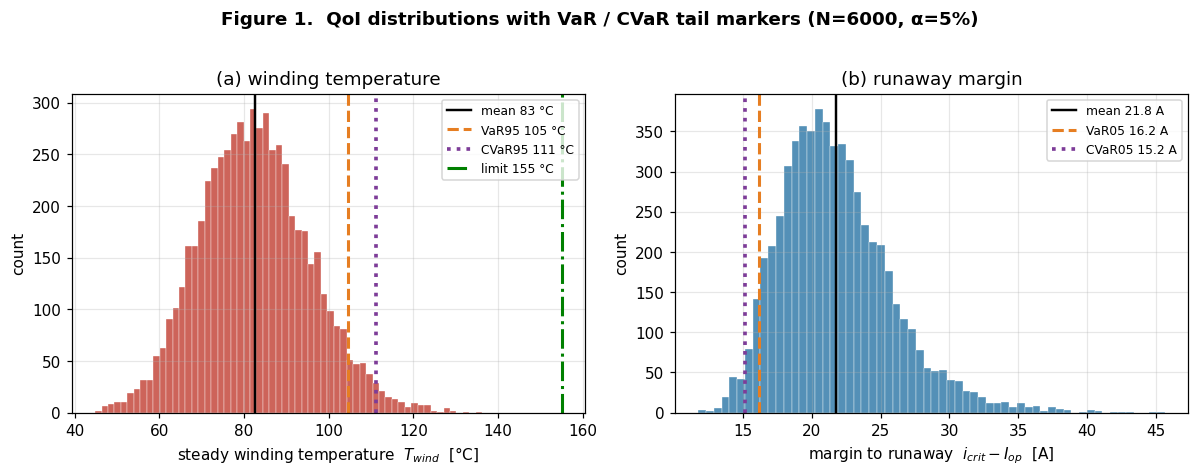

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.hist(Tw, bins=60, color="#c0392b", alpha=0.78, edgecolor="white", linewidth=0.3)
ax.axvline(Tw.mean(), color="black", ls="-",  lw=1.6, label=f"mean {Tw.mean():.0f} °C")
ax.axvline(var_T,     color="#e67e22", ls="--", lw=2.0, label=f"VaR95 {var_T:.0f} °C")
ax.axvline(cvar_T,    color="#7d3c98", ls=":",  lw=2.4, label=f"CVaR95 {cvar_T:.0f} °C")
ax.axvline(T_LIMIT,   color="green",   ls="-.", lw=2.0, label=f"limit {T_LIMIT:.0f} °C")
ax.set_xlabel("steady winding temperature  $T_{wind}$  [°C]")
ax.set_ylabel("count"); ax.set_title("(a) winding temperature"); ax.legend(fontsize=8)

ax = axes[1]
ax.hist(mg, bins=60, color="#2471a3", alpha=0.78, edgecolor="white", linewidth=0.3)
ax.axvline(mg.mean(), color="black", ls="-",  lw=1.6, label=f"mean {mg.mean():.1f} A")
ax.axvline(var_m,     color="#e67e22", ls="--", lw=2.0, label=f"VaR05 {var_m:.1f} A")
ax.axvline(cvar_m,    color="#7d3c98", ls=":",  lw=2.4, label=f"CVaR05 {cvar_m:.1f} A")
ax.set_xlabel("margin to runaway  $i_{crit}-I_{op}$  [A]")
ax.set_ylabel("count"); ax.set_title("(b) runaway margin"); ax.legend(fontsize=8)

fig.suptitle("Figure 1.  QoI distributions with VaR / CVaR tail markers "
             f"(N={N_MC}, α={ALPHA:.0%})", y=1.02, fontweight="bold")
fig.tight_layout(); plt.show()

> **Figure 1.** Monte-Carlo distributions of the two safety QoIs. Left:
> winding temperature — the mean ($\approx 83\,°$C) is comfortable but the
> hot tail (VaR95 $\approx 105\,°$C, CVaR95 $\approx 111\,°$C) approaches the
> $155\,°$C limit; CVaR sits to the right of VaR by construction. Right:
> runaway margin, read from its lower tail — the unlucky 5% of motors have the
> smallest margin (VaR05), and CVaR05 lies further left still.

## 5. Sobol' sensitivity: which parameter owns the risk?

Variance-based (Sobol') sensitivity decomposes the variance of a QoI $Y=f(X)$
into contributions from each input $X_i$ and their interactions. The
**first-order index** is the fraction of $\mathrm{Var}(Y)$ removed *on average*
if $X_i$ were fixed; the **total index** also credits $X_i$ for every
interaction it participates in:

$$
S_i = \frac{\mathrm{Var}_{X_i}\!\big(\mathbb{E}_{X_{\sim i}}[Y \mid X_i]\big)}{\mathrm{Var}(Y)},
\qquad
S_i^{T} = \frac{\mathbb{E}_{X_{\sim i}}\!\big[\mathrm{Var}_{X_i}(Y \mid X_{\sim i})\big]}{\mathrm{Var}(Y)} = 1 - S_{\sim i}.
$$

By construction $0 \le S_i \le S_i^{T} \le 1$, and $S_i^{T}-S_i$ measures how
much $X_i$ acts through interactions. We estimate them with the Saltelli design
inside `jaxonomy.uq.sobol_indices` (here `diagram=None` because our QoI is a
direct analytic function rather than a simulated `DiagramBuilder` output).

In [7]:
sob_T = uq.sobol_indices(diagram=None, t_span=None, distributions=DISTS,
                         qoi_fn=qoi_Twind, n_samples=4096, key=jax.random.fold_in(KEY, 10))

order = sorted(sob_T, key=lambda k: sob_T[k]["total_order"], reverse=True)
print("Sobol' indices for winding temperature (ranked by total order):")
print(f"  {'param':6s} {'S1 (first)':>12s} {'ST (total)':>12s}")
for k in order:
    print(f"  {k:6s} {sob_T[k]['first_order']:12.3f} {sob_T[k]['total_order']:12.3f}")

top = order[0]
print(f"\nTop driver of peak winding temperature: {top}")
print(f"Sum of first-order indices: {sum(v['first_order'] for v in sob_T.values()):.3f} "
      "(≈1 ⇒ nearly additive, little interaction)")
assert top == "R_th", "R_th must dominate peak temperature"

Sobol' indices for winding temperature (ranked by total order):
  param    S1 (first)   ST (total)
  R_th          0.759        0.769
  T_amb         0.189        0.192
  R0            0.020        0.051
  alpha        -0.015        0.002
  lam0         -0.016        0.000
  C_th         -0.016        0.000

Top driver of peak winding temperature: R_th
Sum of first-order indices: 0.922 (≈1 ⇒ nearly additive, little interaction)


$R_{\mathrm{th}}$ alone explains roughly three-quarters of the variance
in winding temperature, with the aleatoric ambient temperature a distant
second and everything else negligible. The first-order indices nearly sum to
one, so the model is close to additive — interactions are small (total $\approx$
first for each parameter). **Figure 2** makes the ranking visual.

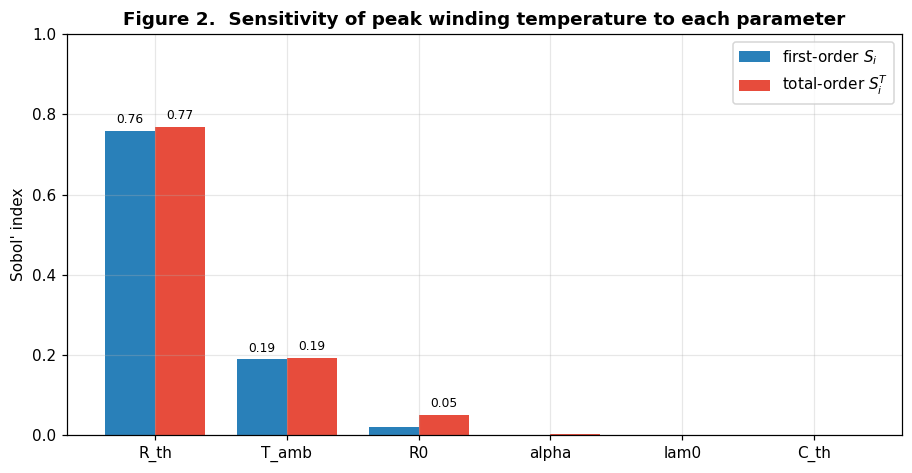

In [8]:
labels = order
s1 = [sob_T[k]["first_order"] for k in labels]
st = [sob_T[k]["total_order"] for k in labels]
x = np.arange(len(labels)); w = 0.38

fig, ax = plt.subplots(figsize=(8.4, 4.4))
b1 = ax.bar(x - w/2, s1, w, label="first-order $S_i$",  color="#2980b9")
b2 = ax.bar(x + w/2, st, w, label="total-order $S_i^T$", color="#e74c3c")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Sobol' index"); ax.set_ylim(0, 1.0)
ax.set_title("Figure 2.  Sensitivity of peak winding temperature to each parameter",
             fontweight="bold")
ax.legend()
for b in list(b1) + list(b2):
    h = b.get_height()
    if h > 0.02:
        ax.text(b.get_x()+b.get_width()/2, h+0.012, f"{h:.2f}",
                ha="center", va="bottom", fontsize=8)
fig.tight_layout(); plt.show()

> **Figure 2.** First-order vs. total Sobol' indices for the winding
> temperature. $R_{\mathrm{th}}$ (the cooling/mounting thermal resistance)
> dominates — it is the one parameter worth spending money to control. The
> near-equality of first and total order for every parameter confirms a
> nearly additive response with weak interactions.

### Morris screening (cheap cross-check)

Sobol' is the gold standard but costs $\mathcal{O}(N\,(d{+}2))$ model
evaluations. **Morris screening** is an order-of-magnitude cheaper one-at-a-time
design: its $\mu^\*$ (mean absolute elementary effect) ranks importance and its
$\sigma$ flags nonlinearity/interaction. We expect it to agree on the ranking.

In [9]:
mor = uq.morris_screening(diagram=None, t_span=None, distributions=DISTS,
                          qoi_fn=qoi_Twind, n_trajectories=40, levels=6,
                          key=jax.random.fold_in(KEY, 11))
mor_rank = sorted(mor, key=lambda k: mor[k]["mu_star"], reverse=True)
print("Morris ranking (by μ*):")
for k in mor_rank:
    print(f"  {k:6s} μ*={mor[k]['mu_star']:.4g}   σ={mor[k]['sigma']:.4g}")
print(f"\nMorris top = {mor_rank[0]}   |   Sobol top = {top}   |   agree: {mor_rank[0] == top}")

Morris ranking (by μ*):
  R_th   μ*=9603   σ=8275
  R0     μ*=49.64   σ=62.73
  alpha  μ*=25.89   σ=63.58
  T_amb  μ*=20   σ=3.275e-15
  lam0   μ*=0   σ=0
  C_th   μ*=0   σ=0

Morris top = R_th   |   Sobol top = R_th   |   agree: True


## 6. From risk to spec: the safe operating current

A reliability requirement is a probabilistic statement, e.g.

$$
\textbf{Spec:}\quad \mathbb{P}\big(T_{\mathrm{wind}} > 155\,°\mathrm{C}\big) < 1\%.
$$

Holding the uncertainty model fixed, the only knob the integrator controls is
the operating current $I_{\mathrm{op}}$. We sweep it, recompute the **99th-
percentile** winding temperature across the sample at each current, and read
off the largest current whose $p_{99}$ still sits under the limit. That current
is the design margin expressed as a number a controls engineer can clamp to.

In [10]:
samp = uq.sample_parameters(DISTS, 4000, jax.random.fold_in(KEY, 20))
i_grid = np.linspace(5.0, 32.0, 220)

def p99_temp(i):
    return float(np.percentile(np.asarray(qoi_Twind(samp, i=i)), 99.0))

p99_curve = np.array([p99_temp(i) for i in i_grid])

def safe_current(limit):
    ok = i_grid[p99_curve <= limit]
    return float(ok.max()) if ok.size else float("nan")

limits = np.array([140.0, 155.0, 170.0])
safe_Is = np.array([safe_current(L) for L in limits])
I_SAFE = safe_current(T_LIMIT)
i_crit_nom = float(i_crit(NOM["R0"], NOM["alpha"], NOM["R_th"]))

print("temperature limit  ->  max safe I_op (P99 ≤ limit)")
for L, I in zip(limits, safe_Is):
    print(f"   {L:6.0f} °C   ->   {I:6.2f} A")
print(f"\nChosen spec: P(T>{T_LIMIT:.0f}°C)<1%  ⇒  I_op ≤ {I_SAFE:.2f} A")
print(f"(nominal i_crit = {i_crit_nom:.2f} A — the safe current is far below runaway)")

# asserts: monotone in limit, and safe current below runaway
assert np.all(np.diff(safe_Is) >= -1e-9), "safe current must be monotone in the limit"
assert I_SAFE < i_crit_nom, "safe operating current must lie below i_crit"

temperature limit  ->  max safe I_op (P99 ≤ limit)
      140 °C   ->    15.48 A
      155 °C   ->    16.34 A
      170 °C   ->    16.96 A

Chosen spec: P(T>155°C)<1%  ⇒  I_op ≤ 16.34 A
(nominal i_crit = 35.14 A — the safe current is far below runaway)


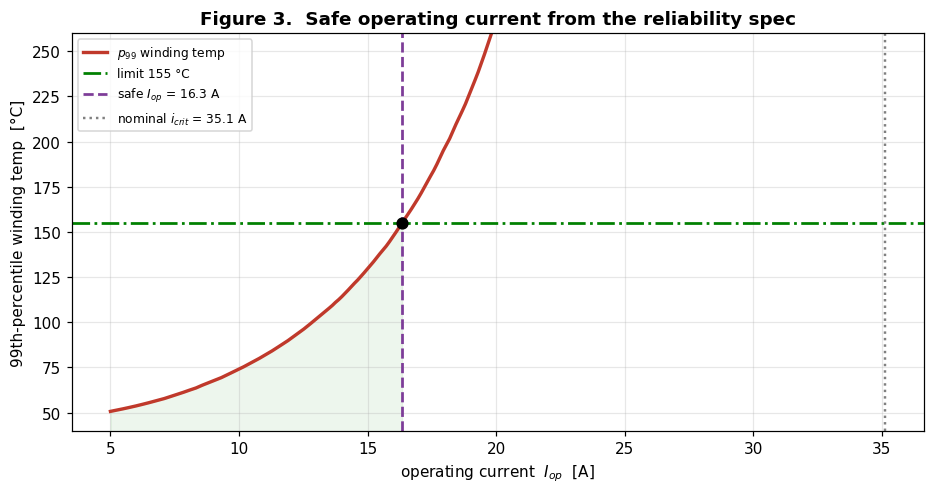

In [11]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.plot(i_grid, p99_curve, color="#c0392b", lw=2.2, label="$p_{99}$ winding temp")
ax.axhline(T_LIMIT, color="green", ls="-.", lw=1.8, label=f"limit {T_LIMIT:.0f} °C")
ax.axvline(I_SAFE,  color="#7d3c98", ls="--", lw=1.8,
           label=f"safe $I_{{op}}$ = {I_SAFE:.1f} A")
ax.axvline(i_crit_nom, color="gray", ls=":", lw=1.6,
           label=f"nominal $i_{{crit}}$ = {i_crit_nom:.1f} A")
ax.plot([I_SAFE], [T_LIMIT], "o", color="black", ms=7, zorder=5)
ax.fill_between(i_grid, 0, p99_curve, where=p99_curve <= T_LIMIT,
                color="green", alpha=0.07)
ax.set_xlabel("operating current  $I_{op}$  [A]")
ax.set_ylabel("99th-percentile winding temp  [°C]")
ax.set_ylim(40, 260)
ax.set_title("Figure 3.  Safe operating current from the reliability spec",
             fontweight="bold")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

> **Figure 3.** The 99th-percentile winding temperature climbs steeply
> with current and diverges as $I_{\mathrm{op}}\to i_{\mathrm{crit}}$. The spec
> $\mathbb{P}(T>155\,°\mathrm{C})<1\%$ is met for all currents left of the
> dashed line. Tightening the limit shifts the safe current down (the table
> above is monotone), and the safe current stays comfortably below the runaway
> current — the *temperature* limit, not runaway, is the binding constraint.

**The design margin, stated plainly:** under ±20% cooling-resistance spread and
a 25–45 °C ambient, the nominal $14\,$A operating point is safe, but the
*headroom* before the 1%-overtemp spec is violated extends only to
$\approx 16\,$A — far less than the $35\,$A runaway current a naïve nominal
analysis would quote as the limit.

## 7. Aleatoric vs. epistemic: how much risk can I buy down?

Finally we split the variance of the winding-temperature QoI into its
aleatoric and epistemic parts. `decompose_variance_sobol` runs a nested design:
the **epistemic** variance is the part removed if the manufacturing/model
parameters were known exactly (reducible — by tolerancing, metrology, or a
calibration step like the one in Parts 2–3); the **aleatoric** variance is what
remains from the operating environment ($T_{\mathrm{amb}}$) and cannot be
designed away — only margined against.

In [12]:
ale = {k: v for k, v in DISTS.items() if v.kind == "aleatoric"}
epi = {k: v for k, v in DISTS.items() if v.kind == "epistemic"}

dec = uq.decompose_variance_sobol(qoi_Twind, ale, epi,
                                  n_samples=4096, key=jax.random.fold_in(KEY, 30))
v_tot = dec["var_total"]; v_ale = dec["var_aleatoric"]; v_epi = dec["var_epistemic"]
f_ale, f_epi = v_ale / v_tot, v_epi / v_tot
print(f"total variance      : {v_tot:8.2f}  °C²")
print(f"  aleatoric (T_amb) : {v_ale:8.2f}  ({f_ale*100:4.1f}%)  — irreducible")
print(f"  epistemic (mfg)   : {v_epi:8.2f}  ({f_epi*100:4.1f}%)  — reducible")
print(f"  interaction       : {dec.get('interaction', 0.0):8.2f}")
assert abs((v_ale + v_epi) / v_tot - 1.0) < 0.2, "variance shares should sum to ~total"

total variance      :   169.97  °C²
  aleatoric (T_amb) :    37.77  (22.2%)  — irreducible
  epistemic (mfg)   :   135.84  (79.9%)  — reducible
  interaction       :    -3.64


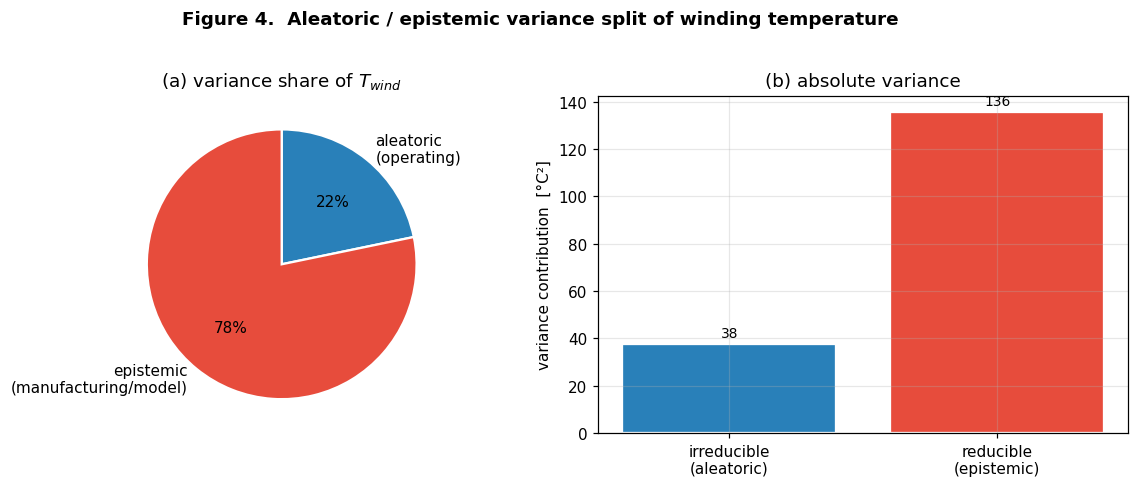

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

axes[0].pie([v_ale, v_epi], labels=["aleatoric\n(operating)", "epistemic\n(manufacturing/model)"],
            autopct="%1.0f%%", startangle=90, counterclock=False,
            colors=["#2980b9", "#e74c3c"], wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[0].set_title("(a) variance share of $T_{wind}$")

axes[1].bar(["irreducible\n(aleatoric)", "reducible\n(epistemic)"], [v_ale, v_epi],
            color=["#2980b9", "#e74c3c"], edgecolor="white", linewidth=1.5)
axes[1].set_ylabel("variance contribution  [°C²]")
for i, v in enumerate([v_ale, v_epi]):
    axes[1].text(i, v + v_tot*0.01, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("(b) absolute variance")

fig.suptitle("Figure 4.  Aleatoric / epistemic variance split of winding temperature",
             y=1.02, fontweight="bold")
fig.tight_layout(); plt.show()

> **Figure 4.** The bulk of the temperature variance is **epistemic** —
> dominated by the poorly-known $R_{\mathrm{th}}$. That is *good news for the
> engineer*: most of the risk is reducible. A qualification step that pins down
> the as-mounted thermal resistance (better mounting spec, measured thermal
> paste coverage, or an in-situ $R_{\mathrm{th}}$ calibration) would collapse
> the hot tail and recover most of the lost operating-current headroom. The
> residual aleatoric slice (ambient temperature) is what you must carry as
> permanent design margin.

## Failure modes

- **Designing to the mean.** The nominal motor runs at $\sim 72\,°$C and the
  *mean* of the distribution is $\sim 83\,°$C — both far under the limit. An
  engineer who sizes to either number ships a fleet in which roughly 1 in 100
  motors exceeds $155\,°$C. **Design to the tail (VaR/CVaR), not the mean.**
- **Ignoring $R_{\mathrm{th}}$ uncertainty.** Treating the cooling resistance
  as a fixed nominal removes ~75% of the temperature variance from the model
  (Fig. 2) and badly *under-predicts* risk — the single most common way a
  thermal margin analysis is wrong. The dominant uncertainty is exactly the one
  that is hardest to pin down on the bench.
- **Confusing the runaway current with the safe current.** $i_{\mathrm{crit}}
  \approx 35\,$A is a *stability* limit; the *thermal* spec binds far earlier
  (~16 A). Quoting $i_{\mathrm{crit}}$ as the rating is a factor-of-two error.
- **Reporting VaR without CVaR.** VaR says nothing about how bad the breach is.
  Two designs with equal VaR can have very different CVaR; a runaway-prone tail
  is invisible to VaR alone.
- **Too few samples in the tail.** A 99th-percentile or 1%-exceedance estimate
  from $N=200$ samples is dominated by sampling noise. Use $N\gtrsim 4000$ (or
  quasi-Monte-Carlo / importance sampling) and seed the RNG for reproducibility.
- **Mislabeling kinds.** Calling reducible manufacturing spread "aleatoric"
  hides an opportunity to engineer the risk away; calling ambient temperature
  "epistemic" invites a metrology project that cannot help.

## Exercises

- **Easy.** Re-run §4 with the ambient range widened to $[20, 55]\,°$C. How do
  VaR95/CVaR95 and the safe current move? Which Sobol' index grows?
- **Medium.** Replace `R_th ~ Normal` with a `LogNormal` of the same mean and
  CoV (cooling resistance is positive and right-skewed in practice). Does the
  hot tail get worse? Re-derive the safe current.
- **Hard.** Add a second QoI constraint — torque shortfall $< 5\%$ at the hot
  point — and find the operating current that satisfies *both* the temperature
  and torque specs simultaneously. Plot the feasible region in
  $(I_{\mathrm{op}}, \text{limit})$ space.
- **Open.** Suppose an in-line calibration can measure each motor's
  $R_{\mathrm{th}}$ to ±5% before deployment (epistemic → near-zero). Quantify
  the recovered operating-current headroom, and decide whether the calibration
  cost is justified by the extra continuous torque it unlocks. Extend with
  `jaxonomy.uq.CorrelatedMarginals` if cooling quality and ambient are coupled.

## References

1. A. Saltelli, M. Ratto, T. Andres, et al. *Global Sensitivity Analysis: The
   Primer.* Wiley, 2008. — Sobol'/Morris methodology and the Saltelli design.
2. I. M. Sobol'. "Global sensitivity indices for nonlinear mathematical models
   and their Monte Carlo estimates." *Mathematics and Computers in Simulation*,
   55(1–3):271–280, 2001. — the variance-decomposition indices used here.
3. R. T. Rockafellar and S. Uryasev. "Optimization of Conditional
   Value-at-Risk." *Journal of Risk*, 2(3):21–41, 2000. — CVaR as a coherent,
   optimizable tail-risk measure.
4. M. D. Morris. "Factorial sampling plans for preliminary computational
   experiments." *Technometrics*, 33(2):161–174, 1991. — Morris screening.

## Next steps

→ **Part 6: embedded deployment.** With a margin-qualified operating envelope
in hand — a safe operating current and a known, $R_{\mathrm{th}}$-dominated
risk budget — the final part lowers the controller and the derating logic onto
an Arm target, carrying the temperature limit and operating-current clamp from
this analysis into the deployed firmware.
